In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"  
# os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  
from torch import nn


import numpy as np                                       
                           
import torch                                          

                              
from transformers import AutoModelForCausalLM, AutoTokenizer  
from tqdm import tqdm
import matplotlib.pyplot as plt  
import torch.nn.functional as F
import gc
import re
import copy

import sys
sys.path.append('..')
import JCBScope_utils

# Move to GPU with optimal dtype
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = "cpu"


/home/jl3499/conda/LLM1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jl3499/conda/LLM1/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


### Import pre-computed ranking

In [2]:
# mode = 'Temperature'
# mode = 'Semantic'
# mode = 'gradient_x_input'
# mode = 'Random'
# mode = 'IG'
mode = 'Fisher'
presence_list = [0.2, 0.4, 0.6, 0.8, 1.0] 

In [3]:
import json

with open("../results/Llama-3.2-1B__LOO_KL_lambada_loo_results.json") as f:
    loo_results = json.load(f)

len(loo_results['results'])

100

In [4]:
# Load the tokenizer and model

model_name = "meta-llama/Llama-3.2-1B"
model_name_short = model_name.split("/")[-1]
if device == "cpu":
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    model = model.to(device)
else:
    tokenizer = AutoTokenizer.from_pretrained(model_name, device_map="auto")
    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")
    
embedding_layer = model.get_input_embeddings()
embed_device = embedding_layer.weight.device    

In [5]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (ro

In [6]:
front_pad = 0
back_pad = 0

front_strip = 0

# Get special tokens if available
bos_token_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.cls_token_id
eos_token_id = tokenizer.eos_token_id if tokenizer.eos_token_id is not None else tokenizer.sep_token_id


In [7]:
if mode in ('Semantic', 'IG', 'Fisher'):
    unnormalized_logits = True
else:
    unnormalized_logits = False
    

def _fisher_hidden_from_logits_and_W(logits_t, W, chunk_size=8192):
    """Fx [d,d] = W^T (Diag(p) - p p^T) W. logits_t: [V], W: [V,d]."""
    p = F.softmax(logits_t, dim=-1).to(dtype=W.dtype)
    V, d = W.shape
    S = torch.zeros(d, d, device=W.device, dtype=W.dtype)
    mu = torch.zeros(d, device=W.device, dtype=W.dtype)
    for i in range(0, V, chunk_size):
        Wi = W[i:i+chunk_size]
        pi = p[i:i+chunk_size].unsqueeze(1)
        Ww = Wi * pi
        S += Wi.T @ Ww
        mu += Ww.sum(dim=0)
    return S - torch.outer(mu, mu)


def _compute_fisher_scope_scores(forward_pass, residual, loss_position, lm_head, n_tokens, d_model, batch_size=16):
    """Full Jacobian -> FIM per token -> trace as influence score."""
    projection_probes = torch.eye(d_model, d_model, device=residual.device, dtype=residual.dtype)
    losses, logits = forward_pass(loss_position=loss_position, projection_probe=projection_probes)
    num_losses = losses.numel()
    grads_list = []
    for i in range(0, num_losses, batch_size):
        end = min(i + batch_size, num_losses)
        eye_batch = torch.eye(num_losses, device=losses.device, dtype=losses.dtype)[i:end]
        g = torch.autograd.grad(
            outputs=losses, inputs=residual, grad_outputs=eye_batch,
            is_grads_batched=True, retain_graph=(end < num_losses),
        )[0]
        grads_list.append(g)
    grads = torch.cat(grads_list, dim=0)
    del grads_list, losses
    J_all = grads.detach().swapaxes(0, 1)
    del grads
    W = lm_head.weight.to(residual.device, dtype=residual.dtype)
    logits_t = logits[loss_position].to(residual.device)
    Fx = _fisher_hidden_from_logits_and_W(logits_t, W)
    tmp = Fx.unsqueeze(0) @ J_all
    F_all = J_all.transpose(1, 2) @ tmp
    grad_vals = np.array([torch.trace(F_all[i]).item() for i in range(n_tokens)])
    return grad_vals.astype(np.float32), logits


def get_influence_ranking(string):
    """Compute influence scores (Temperature or Semantic scope), return most influential token index."""
    input_ids_list = tokenizer(string, add_special_tokens=False)["input_ids"]
    if eos_token_id is not None:
        input_ids_list += [eos_token_id] * back_pad

    decoded_tokens = [tokenizer.decode([tid], skip_special_tokens=True) for tid in input_ids_list]
    grad_idx = [idx for idx in range(front_pad, len(decoded_tokens), 1)][front_strip:]
    tick_label_text = [decoded_tokens[idx] for idx in grad_idx]

    if mode == 'Random':
        most_influential_local_idx = int(np.random.randint(0, len(grad_idx)))
        most_influential_idx = grad_idx[most_influential_local_idx]
        grad_vals = np.random.random(len(grad_idx)).astype(np.float32)
        ablated_indices = np.array([most_influential_local_idx])
        return most_influential_idx, grad_vals, ablated_indices, tick_label_text, grad_idx

    global model, embedding_layer, embed_device
    if device != "cpu":
        gc.collect()
        torch.cuda.empty_cache()
        model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")
        embedding_layer = model.get_input_embeddings()
        embed_device = embedding_layer.weight.device

    input_ids = torch.tensor([input_ids_list], dtype=torch.long).to(embed_device)
    attention_mask = torch.ones_like(input_ids, device=embed_device)
    seq_len = input_ids.size(1)

    d_model = embedding_layer.embedding_dim
    residual = nn.Parameter(torch.zeros(len(grad_idx), d_model, device=embed_device))
    presence = torch.ones(len(decoded_tokens), 1, device=embed_device)
    model.eval()
    forward_pass = JCBScope_utils.customize_forward_pass(
        model, residual, presence, input_ids, grad_idx, attention_mask
    )
    hidden_norm_as_loss = (mode == 'Temperature')
    loss_position = seq_len - 2

    if mode == 'Fisher':
        lm_head = JCBScope_utils.get_lm_head(model)
        grad_vals, logits_orig = _compute_fisher_scope_scores(
            forward_pass, residual, loss_position, lm_head, len(grad_idx), d_model
        )
    elif mode == 'IG':
        grad_list = []
        for alpha in presence_list:
            loss, logits_orig = forward_pass(
                loss_position=loss_position,
                hidden_norm_as_loss=hidden_norm_as_loss,
                unnormalized_logits=True,
                tie_input_output_embed=False,
                alpha=alpha,
            )
            g = torch.autograd.grad(loss, residual, retain_graph=False)[0]
            grad_list.append(g.detach().clone())
            del loss
        grads = torch.stack(grad_list).mean(dim=0)
        del grad_list
        with torch.no_grad():
            token_embeds = embedding_layer(input_ids[0, grad_idx])
        grad_vals = (grads * token_embeds).norm(dim=-1).squeeze().cpu().numpy()
    else:
        loss, logits_orig = forward_pass(
            loss_position=loss_position,
            hidden_norm_as_loss=hidden_norm_as_loss,
            unnormalized_logits=True,
            tie_input_output_embed=False,
        )
        grads = torch.autograd.grad(loss, residual, retain_graph=False)[0]
        del loss
        if mode == 'gradient_x_input':
            with torch.no_grad():
                token_embeds = embedding_layer(input_ids[0, grad_idx])
            grad_vals = (grads * token_embeds).norm(dim=-1).squeeze().cpu().numpy()
        else:
            grad_vals = grads.norm(dim=-1).squeeze().cpu().numpy()
    if grad_vals.ndim > 1:
        grad_vals = grad_vals.squeeze()

    most_influential_local_idx = int(np.argmax(grad_vals))
    most_influential_idx = grad_idx[most_influential_local_idx]
    ablated_indices = np.array([most_influential_local_idx])

    # del model
    gc.collect()
    if device != "cpu":
        torch.cuda.empty_cache()

    return most_influential_idx, grad_vals, ablated_indices, tick_label_text, grad_idx

In [8]:
import json
from pathlib import Path

# 1. Load each prompt from loo_results['results']
# 2. Use temperature/semantic scope to get most influential token index
# 3. Locate this index in ranked_token_indices (LOO ranking)
# 4. Save rank and ranking_pct into each result, with mode name in key

loo_json_path = Path("../results/Llama-3.2-1B__LOO_KL_lambada_loo_results.json")
with open(loo_json_path, "r", encoding="utf-8") as f:
    loo_results = json.load(f)

for i, item in enumerate(tqdm(loo_results["results"], desc="Processing prompts")):
    if f"{mode}_rank" in item:
        continue
    prompt = item["prompt"]
    ranked_token_indices = item["ranked_token_indices"]
    print(prompt)
    
    most_influential_idx, grad_vals, ablated_indices, tick_label_text, grad_idx = get_influence_ranking(prompt)

    if most_influential_idx in ranked_token_indices:
        rank = ranked_token_indices.index(most_influential_idx)
        ranking_pct = (rank / len(ranked_token_indices)) * 100
    else:
        rank = None
        ranking_pct = None

    
    item[f"{mode}_rank"] = rank
    item[f"{mode}_ranking_pct"] = ranking_pct
    print(f"[{i}] {mode}_rank = {rank}, {mode}_ranking_pct = {ranking_pct:.2g}" if ranking_pct is not None else f"[{i}] {mode}_rank = {rank}, {mode}_ranking_pct = None")
    most_influential_token_scope = tick_label_text[grad_idx[most_influential_idx]]
    print(f"Most influential token index (by {mode} scope): {most_influential_token_scope}")
    most_influential_token_loo = tick_label_text[ranked_token_indices[0]]
    print(f"Most influential token index (by LOO): {most_influential_token_loo}")


    if (i + 1) <= 3:
        _last_grad_vals, _last_ablated, _last_tick = grad_vals, ablated_indices, tick_label_text

    with open(loo_json_path, "w", encoding="utf-8") as f:
        json.dump(loo_results, f, indent=2, ensure_ascii=False)




Processing prompts:   0%|          | 0/100 [00:00<?, ?it/s]

Neither Anna nor Father would ever venture beyond the prescribed social parameters to converse with each other, as long as she was out of sight and not seen alone by either of them she would have the day to herself. Her only concern was covering her tracks afterwards, but those details could be dealt with later in the day, once the sun was directly overhead and it was too hot to walk, to explore, and to experience this rare freedom.
At the top of the hill she turned the corner quickly, taking a side street which wound through the back of her neighborhood


/home/jl3499/conda/LLM1/lib/python3.12/site-packages/torch/autograd/graph.py:769: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1742433629875/work/aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Processing prompts:  68%|██████▊   | 68/100 [03:25<01:36,  3.03s/it]

[67] Fisher_rank = 2, Fisher_ranking_pct = 1.8
Most influential token index (by Fisher scope):  of
Most influential token index (by LOO):  her
They follow them for a quarter of a mile, at which point, the vampires had begun to assemble themselves into a line, almost like an invisible funnel forced them.
They followed the line, and it led them to a curved road where half a dozen semi trucks were parked. The vampires crawled into their beds and stood face to face in them.
As the first one got full, the line moved to the second and third truck


Processing prompts:  69%|██████▉   | 69/100 [06:20<03:23,  6.55s/it]

...

[97] Fisher_rank = 1, Fisher_ranking_pct = 1.3
Most influential token index (by Fisher scope):  Fang
Most influential token index (by LOO): ,
I made a mental list of the most likely places Airi might have gone and checked my map to see if I could check them in some kind of order. At night, when it got too dark to keep searching, I thought it would be a good idea to get to the highest point I could find and hope to see moving lights in the dark areas where the grid had failed, indicating survivors. I knew it was a really long shot, but if there were survivors out there maybe they had seen Airi


Processing prompts:  99%|█████████▉| 99/100 [1:35:39<03:04, 184.33s/it]

[98] Fisher_rank = 0, Fisher_ranking_pct = 0
Most influential token index (by Fisher scope): i
Most influential token index (by LOO): i
After years of working to get her life on track, she finally had a decent job, a great husband, and the smartest, most beautiful baby boy ever born. He was only three weeks old, but she was certain he was destined for great things.

She could hardly wait to show Cory off to her friend Isabelle.

The doorbell rang five minutes early, but that was just like Isabelle


Processing prompts: 100%|██████████| 100/100 [1:39:23<00:00, 59.64s/it] 

[99] Fisher_rank = 1, Fisher_ranking_pct = 1.2
Most influential token index (by Fisher scope): abelle
Most influential token index (by LOO):  Is


In [9]:
# # Save ranking and ranking_pct back to the same JSON file
# with open(loo_json_path, "w", encoding="utf-8") as f:
#     json.dump(loo_results, f, indent=2, ensure_ascii=False)
# print(f"Saved {len(loo_results['results'])} results with {mode}_rank and {mode}_ranking_pct to {loo_json_path}")


In [10]:
mode

'Fisher'

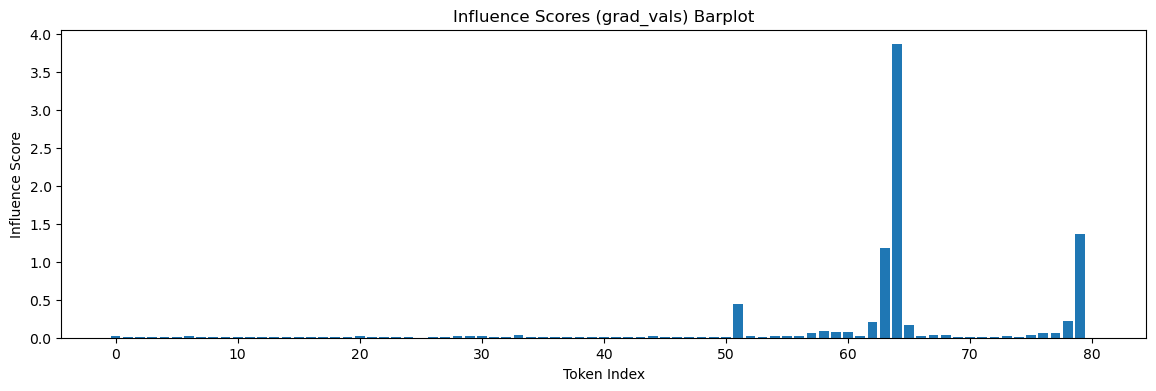

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# grad_vals is expected to be a list or array of influence values for each token
if isinstance(grad_vals, np.ndarray):
    values = grad_vals
else:
    values = np.array(grad_vals)

plt.figure(figsize=(14, 4))
plt.bar(np.arange(len(values)), values)
plt.title("Influence Scores (grad_vals) Barplot")
plt.xlabel("Token Index")
plt.ylabel("Influence Score")
plt.show()

In [12]:
## Summary: {mode} scope most influential token rank in LOO ranking
results = loo_results["results"]
rank_key, pct_key = f"{mode}_rank", f"{mode}_ranking_pct"
for i, r in enumerate(results):
    rank = r.get(rank_key)
    pct = r.get(pct_key)
    rank_str = str(rank) if rank is not None else "N/A"
    pct_str = f"{pct:.2f}%" if pct is not None else "N/A"
    print(f"[{i}] rank={rank_str}  ranking_pct={pct_str}")
    

[0] rank=0  ranking_pct=0.00%
[1] rank=2  ranking_pct=1.90%
[2] rank=1  ranking_pct=1.22%
[3] rank=8  ranking_pct=10.13%
[4] rank=2  ranking_pct=2.38%
[5] rank=0  ranking_pct=0.00%
[6] rank=3  ranking_pct=3.66%
[7] rank=1  ranking_pct=1.25%
[8] rank=1  ranking_pct=1.52%
[9] rank=1  ranking_pct=1.37%
[10] rank=3  ranking_pct=3.26%
[11] rank=1  ranking_pct=1.18%
[12] rank=1  ranking_pct=1.32%
[13] rank=2  ranking_pct=2.11%
[14] rank=0  ranking_pct=0.00%
[15] rank=7  ranking_pct=9.59%
[16] rank=58  ranking_pct=72.50%
[17] rank=2  ranking_pct=1.61%
[18] rank=1  ranking_pct=0.96%
[19] rank=1  ranking_pct=1.18%
[20] rank=3  ranking_pct=3.37%
[21] rank=5  ranking_pct=6.41%
[22] rank=3  ranking_pct=3.90%
[23] rank=1  ranking_pct=1.25%
[24] rank=3  ranking_pct=3.80%
[25] rank=8  ranking_pct=7.77%
[26] rank=2  ranking_pct=2.78%
[27] rank=4  ranking_pct=5.71%
[28] rank=1  ranking_pct=1.30%
[29] rank=19  ranking_pct=25.33%
[30] rank=2  ranking_pct=2.86%
[31] rank=1  ranking_pct=1.52%
[32] rank=3  

In [13]:

from math import sqrt

# Report ranking stats: where does the most influential token (by {mode} scope) rank in LOO?
rank_key, pct_key = f"{mode}_rank", f"{mode}_ranking_pct"
ranks = [r[rank_key] for r in results if r.get(rank_key) is not None]
pcts = [r[pct_key] for r in results if r.get(pct_key) is not None]
total = len(results)

if ranks:
    avg_rank = sum(ranks) / len(ranks)
    avg_pct = sum(pcts) / len(pcts) if pcts else float("nan") 

    # Compute SEM (standard error of the mean) for mean_ranking_pct if possible
    sem_ranking_pct = None
    if pcts and len(pcts) > 1:
        mean_pct = sum(pcts) / len(pcts)
        variance_pct = sum((x - mean_pct) ** 2 for x in pcts) / (len(pcts) - 1)
        sem_ranking_pct = sqrt(variance_pct / len(pcts))

    print(f"\n{mode} scope vs LOO ranking ({len(ranks)}/{total} prompts):")
    print(f"  Mean rank of most influential token in LOO: {avg_rank:.2f}")
    if sem_ranking_pct is not None:
        print(f"  Mean ranking percentile: {avg_pct:.2f} ± {sem_ranking_pct:.2f}%")
    else:
        print(f"  Mean ranking percentile: {avg_pct:.2f}%")
else:
    print("No rank data. Run the processing cell first.")

# Calculate how often most influential token's ranking percentile is within 5% of the top
within_5_pct_count = sum(1 for r in results if r.get(pct_key) is not None and r[pct_key] <= 5)
fraction_within_5_pct = within_5_pct_count / total if total else 0
print(f"\n{mode} scope most influential token is within top 5% of LOO ranking for {within_5_pct_count}/{total} prompts ({fraction_within_5_pct:.1%})")

# Save to master_results.json
label = f"Llama-3.2-1B__{mode}_lambada_loo_rank"
master_path = Path("../results/master_results.json")
master_path.parent.mkdir(parents=True, exist_ok=True)
master = {}
if master_path.exists():
    with open(master_path, "r", encoding="utf-8") as f:
        master = json.load(f)

entry = {
    "mean_rank": sum(ranks) / len(ranks) if ranks else None,
    "mean_ranking_pct": sum(pcts) / len(pcts) if pcts else None,
    "sem_mean_ranking_pct": sem_ranking_pct,
    "n_with_rank": len(ranks),
    "total": total,
    "within_top5_pct_count": within_5_pct_count,
    "fraction_within_top5_pct": fraction_within_5_pct,
}
master[label] = entry
with open(master_path, "w", encoding="utf-8") as f:
    json.dump(master, f, indent=2)
print(f"\nSaved to {master_path} (label={label})")




Fisher scope vs LOO ranking (100/100 prompts):
  Mean rank of most influential token in LOO: 4.78
  Mean ranking percentile: 5.90 ± 1.12%

Fisher scope most influential token is within top 5% of LOO ranking for 72/100 prompts (72.0%)

Saved to ../results/master_results.json (label=Llama-3.2-1B__Fisher_lambada_loo_rank)
